# Mnist classification with Nns
Un primo esempio di una rete neurale applicata al datset mnist


In [9]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras import utils
import numpy as np

Si carica il dataset

In [10]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train.shape)
print("pixel range is [{},{}]".format(np.min(x_train),np.max(x_train)))

(60000, 28, 28)
pixel range is [0,255]


Si normalizza l'input nel range [0,1]

In [11]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train,(60000,784))
x_test = np.reshape(x_test,(10000,784))

tf.keras.utils.to_categorical()

In [12]:
print(y_train[0])
y_train_cat = utils.to_categorical(y_train)
print(y_train_cat[0])
y_test_cat = utils.to_categorical(y_test)

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


La prima rete implementa solo la [[Regressione logistica]]

In [15]:
xin = Input(shape=(784))
res = Dense(10,activation='softmax')(xin)

mynet = Model(inputs=xin,outputs=res)

In [16]:
mynet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Ora si necessita di compilare la rete.
Per farlo bisogna passargli 2 argomenti obbligatori:

*   l'**optimizer**, col compito di governare i dettagli dell'algoritmo di backpropagation
*   la **loss function**

Esistono molti optimizer predefiniti, quindi si dovrebbe scegliere il nostro preferito. Quello più comune è _Adam_, implementante un rateo di apprendimento adattivo con momentum

Opzionalmente, si può specificare metriche addizionali, usate principalmente per monitorare il processo di training

In [17]:
mynet.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

Ora si fitta il modello sul training set

Fittare richiede 2 argomenti: dati di training e _ground truth_, che saranno $x$ e $y$. In più si possono specificare epochs, dimensione del [[Tecnica del gradiente#^dd071f|batch]] e altri argomenti

In particolare, passare dati di validazione permette alla procedura di training di misurare _loss_ e _metriche_ sul _validation set_ alla fine di ogni _epoch_

In [19]:
mynet.fit(x_train,y_train_cat, shuffle=True, epochs=15, batch_size=32,validation_data=(x_test,y_test_cat))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9316 - loss: 0.2449 - val_accuracy: 0.9288 - val_loss: 0.2622
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9301 - loss: 0.2474 - val_accuracy: 0.9243 - val_loss: 0.2684
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9327 - loss: 0.2462 - val_accuracy: 0.9261 - val_loss: 0.2697
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9339 - loss: 0.2374 - val_accuracy: 0.9275 - val_loss: 0.2661
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9327 - loss: 0.2419 - val_accuracy: 0.9283 - val_loss: 0.2657
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9365 - loss: 0.2315 - val_accuracy: 0.9273 - val_loss: 0.2665
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9349 - loss: 0.2421 - val_accuracy: 0.9274 - val_loss: 0.2660
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9351 - loss: 0.2382 - 

In [21]:
xin = Input(shape=(784,))
x = Dense(128,activation='relu')(xin)
res = Dense(10,activation='softmax')(x)

mynet2 = Model(inputs=xin,outputs=res)

In [22]:
mynet2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
mynet2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [24]:
mynet2.fit(x_train,y_train_cat, shuffle=True, epochs=10, batch_size=32,validation_data=(x_test,y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8757 - loss: 0.4337 - val_accuracy: 0.9554 - val_loss: 0.1508
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9642 - loss: 0.1208 - val_accuracy: 0.9704 - val_loss: 0.0993
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9770 - loss: 0.0792 - val_accuracy: 0.9712 - val_loss: 0.0954
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9819 - loss: 0.0604 - val_accuracy: 0.9731 - val_loss: 0.0889
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9868 - loss: 0.0444 - val_accuracy: 0.9755 - val_loss: 0.0818
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9905 - loss: 0.0319 - val_accuracy: 0.9807 - val_loss: 0.0688
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0253 - val_accuracy: 0.9750 - val_loss: 0.0873
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9939 - loss: 0.0201 - 

Un incredibile miglioramento.

# Exercises








# 1. Aggiungere un altro dense layer e controllare le performance della rete

In [28]:
xin = Input(shape=(784,))
x = Dense(128,activation='relu')(xin)
x = Dense(128,activation='relu')(x)
res = Dense(10,activation='softmax')(x)

mynet3 = Model(inputs=xin, outputs=res)

In [29]:
mynet3.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
mynet3.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
mynet3.fit(x_train,y_train_cat, shuffle=True, epochs=10, batch_size=32,validation_data=(x_test,y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8826 - loss: 0.4010 - val_accuracy: 0.9624 - val_loss: 0.1270
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9690 - loss: 0.1017 - val_accuracy: 0.9715 - val_loss: 0.0980
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9792 - loss: 0.0668 - val_accuracy: 0.9738 - val_loss: 0.0790
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9843 - loss: 0.0500 - val_accuracy: 0.9714 - val_loss: 0.0982
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9867 - loss: 0.0406 - val_accuracy: 0.9748 - val_loss: 0.0870
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9890 - loss: 0.0325 - val_accuracy: 0.9742 - val_loss: 0.0902
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.9726 - val_loss: 0.1017
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9922 - loss: 0.0239 - 

# 2. Rimpiazzare 'relu' con un altra funzione di attivazione

In [32]:
xin = Input(shape=(784,))
x = Dense(128,activation='tanh')(xin)
res = Dense(10,activation='softmax')(x)

mynet4 = Model(inputs=xin, outputs=res)

In [33]:
mynet4.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
mynet4.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [35]:
mynet4.fit(x_train,y_train_cat, shuffle=True, epochs=10, batch_size=32,validation_data=(x_test,y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8680 - loss: 0.4427 - val_accuracy: 0.9516 - val_loss: 0.1626
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9573 - loss: 0.1474 - val_accuracy: 0.9627 - val_loss: 0.1228
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9708 - loss: 0.0959 - val_accuracy: 0.9713 - val_loss: 0.0914
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9803 - loss: 0.0680 - val_accuracy: 0.9742 - val_loss: 0.0844
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9859 - loss: 0.0488 - val_accuracy: 0.9776 - val_loss: 0.0759
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9898 - loss: 0.0382 - val_accuracy: 0.9757 - val_loss: 0.0762
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9932 - loss: 0.0293 - val_accuracy: 0.9762 - val_loss: 0.0767
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9949 - loss: 0.0215 -

# 3. Adattare la rete per lavorare con la _sparse_categorical_crossentropy_

In [36]:
xin = Input(shape=(784,))
x = Dense(128,activation='relu')(xin)
res = Dense(10,activation='softmax')(x)

mynet5 = Model(inputs=xin, outputs=res)

In [37]:
mynet5.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
mynet5.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [41]:
mynet5.fit(x_train,y_train, shuffle=True, epochs=10, batch_size=32,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9800 - val_loss: 0.0815
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9785 - val_loss: 0.0895
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9972 - loss: 0.0094 - val_accuracy: 0.9774 - val_loss: 0.0842
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9982 - loss: 0.0067 - val_accuracy: 0.9737 - val_loss: 0.1082
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9801 - val_loss: 0.0912
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9778 - val_loss: 0.1006
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9986 - loss: 0.0058 - val_accuracy: 0.9760 - val_loss: 0.1069
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9989 - loss: 0.0041 

# 4. La funzione di fit ritorna una cronologia di training, con sequenze temporali per tutte le diverse metriche. Fare un plot.

In [46]:
import matplotlib.pyplot as plt

In [52]:
n_epochs = 25
accuracy2 = mynet2.fit(x_train,y_train_cat, shuffle=True, epochs=n_epochs, batch_size=32,validation_data=(x_test,y_test_cat))
accuracy3 = mynet3.fit(x_train,y_train_cat, shuffle=True, epochs=n_epochs, batch_size=32,validation_data=(x_test,y_test_cat))
accuracy4 = mynet4.fit(x_train,y_train_cat, shuffle=True, epochs=n_epochs, batch_size=32,validation_data=(x_test,y_test_cat))
accuracy5 = mynet5.fit(x_train,y_train, shuffle=True, epochs=n_epochs, batch_size=32,validation_data=(x_test,y_test))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9985 - loss: 0.0045 - val_accuracy: 0.9796 - val_loss: 0.1055
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9988 - loss: 0.0038 - val_accuracy: 0.9798 - val_loss: 0.1096
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9984 - loss: 0.0052 - val_accuracy: 0.9773 - val_loss: 0.1203
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9988 - loss: 0.0036 - val_accuracy: 0.9786 - val_loss: 0.1081
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9985 - loss: 0.0043 - val_accuracy: 0.9775 - val_loss: 0.1223
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 0.9784 - val_loss: 0.1189
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9783 - val_loss: 0.1227
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9984 - loss: 0.0047 

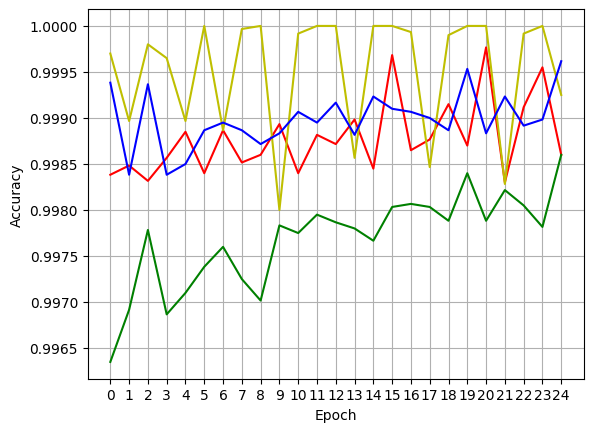

In [53]:
plt.grid(True)
plt.xticks(range(0,n_epochs))
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(accuracy2.history['accuracy'], color= 'r')
plt.plot(accuracy3.history['accuracy'], color= 'g')
plt.plot(accuracy4.history['accuracy'], color= 'y')
plt.plot(accuracy5.history['accuracy'], color= 'b')

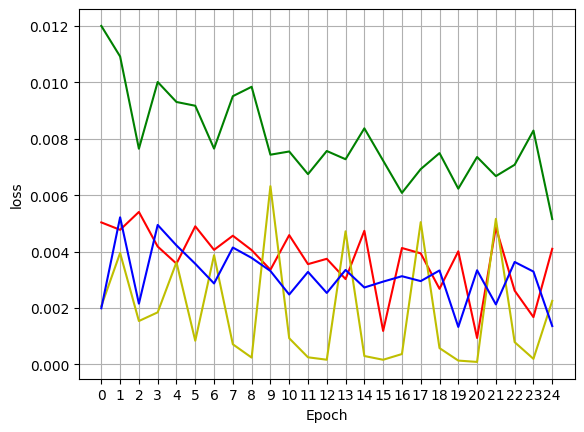

In [54]:
plt.grid(True)
plt.xticks(range(0,n_epochs))
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.plot(accuracy2.history['loss'], color= 'r')
plt.plot(accuracy3.history['loss'], color= 'g')
plt.plot(accuracy4.history['loss'], color= 'y')
plt.plot(accuracy5.history['loss'], color= 'b')

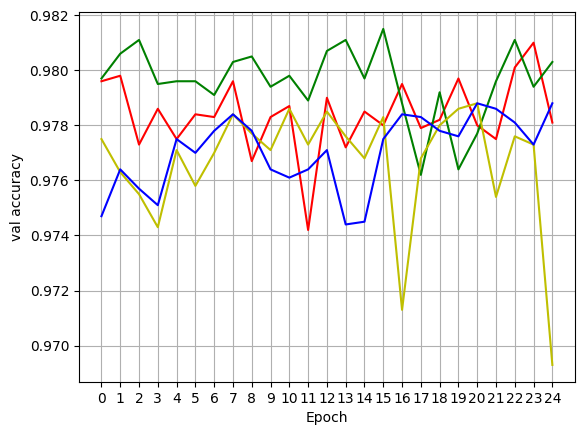

In [55]:
plt.grid(True)
plt.xticks(range(0,n_epochs))
plt.xlabel('Epoch')
plt.ylabel('val accuracy')
plt.plot(accuracy2.history['val_accuracy'], color= 'r')
plt.plot(accuracy3.history['val_accuracy'], color= 'g')
plt.plot(accuracy4.history['val_accuracy'], color= 'y')
plt.plot(accuracy5.history['val_accuracy'], color= 'b')

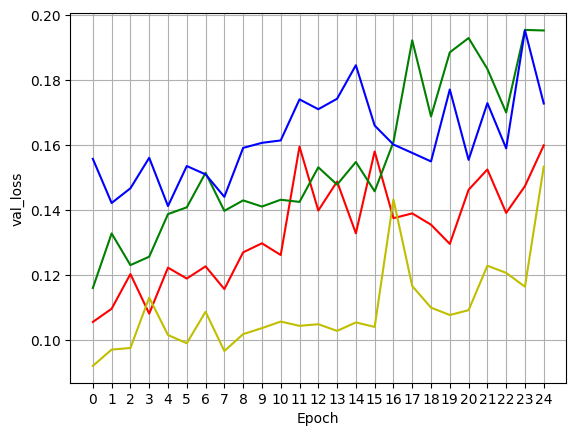

In [56]:
plt.grid(True)
plt.xticks(range(0,n_epochs))
plt.xlabel('Epoch')
plt.ylabel('val_loss')
plt.plot(accuracy2.history['val_loss'], color= 'r')
plt.plot(accuracy3.history['val_loss'], color= 'g')
plt.plot(accuracy4.history['val_loss'], color= 'y')
plt.plot(accuracy5.history['val_loss'], color= 'b')